# ALDIMI Predict - Hito 2

## Baseline de clasificación con Árbol de Decisión

Este notebook desarrolla un modelo base para predecir el `nivel_prioridad_atencion` de pacientes de ALDIMI a partir del archivo `pacientes_riesgo_sintetico.csv` incluido en el ZIP del dataset.

## 1. Importación de librerías

In [2]:
from pathlib import Path
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42

## 2. Carga y descompresión automática del dataset

El notebook usa rutas relativas desde la carpeta actual. Si el ZIP existe, se descomprime automáticamente. Si la carpeta ya existe, se reutiliza.

In [3]:
BASE_DIR = Path(".").resolve()
ZIP_NAME = "ALDIMI_synthetic_dataset_v2_ampliado.zip"
DATASET_DIR = BASE_DIR / "ALDIMI_synthetic_dataset_v2_ampliado"
DATA_DIR = DATASET_DIR / "datos"
ZIP_PATH = BASE_DIR / ZIP_NAME

print(f"Carpeta de trabajo: {BASE_DIR}")

if ZIP_PATH.exists():
    print(f"ZIP encontrado: {ZIP_PATH.name}")
    if not DATA_DIR.exists():
        print("Descomprimiendo dataset...")
        with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
            zip_ref.extractall(BASE_DIR)
        print("Dataset descomprimido correctamente.")
    else:
        print("La carpeta de datos ya existe. Se reutilizará la versión descomprimida.")
else:
    print(f"No se encontró {ZIP_NAME}. Se intentará usar la carpeta descomprimida si existe.")

csv_path = DATA_DIR / "pacientes_riesgo_sintetico.csv"

if not csv_path.exists():
    raise FileNotFoundError(
        "No se encontró pacientes_riesgo_sintetico.csv. "
        "Verifica que el ZIP esté en la misma carpeta del notebook o que la carpeta datos exista."
    )

print(f"Archivo de pacientes localizado en: {csv_path.relative_to(BASE_DIR)}")

Carpeta de trabajo: C:\Users\Diego\Downloads\ALDIMI V2
No se encontró ALDIMI_synthetic_dataset_v2_ampliado.zip. Se intentará usar la carpeta descomprimida si existe.
Archivo de pacientes localizado en: ALDIMI_synthetic_dataset_v2_ampliado\datos\pacientes_riesgo_sintetico.csv


## 3. Lectura del CSV de pacientes

In [4]:
df = pd.read_csv(csv_path)
df.head()

,paciente_id,fecha_registro,edad,sexo,region_origen,diagnostico_general,estado_tratamiento,dias_hospedaje,num_controles_mes,num_quimios_mes,...,temperatura_c,peso_kg,imc,distancia_origen_km,ingreso_familiar_mensual,acompanante_presente,seguro_salud,alfabetizacion_digital,requiere_apoyo_psicosocial,nivel_prioridad_atencion
0,PAC00001,2025-10-06,11,F,Lima,Leucemia linfoblástica aguda,En tratamiento,51,5,0,...,37.3,42.5,15.4,163.9,606.0,1,EsSalud,Baja,1,Medio
1,PAC00002,2025-04-04,15,F,Cusco,Linfoma,En tratamiento,32,1,2,...,37.0,49.8,14.6,132.7,584.0,1,SIS,Baja,0,Bajo
2,PAC00003,2025-03-30,4,F,La Libertad,Leucemia mieloide,Recaída,127,1,3,...,37.8,21.6,16.3,80.7,279.0,1,Privado,Baja,0,Medio
3,PAC00004,2025-02-18,15,F,Puno,Leucemia linfoblástica aguda,En tratamiento,32,1,2,...,37.6,49.8,14.0,250.5,636.0,1,SIS,Baja,1,Medio
4,PAC00005,2025-09-01,9,M,Cajamarca,Tumor sólido,Inicio,89,1,1,...,37.2,29.6,18.0,119.3,416.0,1,SIS,Media,0,Bajo


## 4. Revisión inicial del dataset

In [5]:
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
display(df.head())

Dimensiones del dataset: 10000 filas x 23 columnas


,paciente_id,fecha_registro,edad,sexo,region_origen,diagnostico_general,estado_tratamiento,dias_hospedaje,num_controles_mes,num_quimios_mes,...,temperatura_c,peso_kg,imc,distancia_origen_km,ingreso_familiar_mensual,acompanante_presente,seguro_salud,alfabetizacion_digital,requiere_apoyo_psicosocial,nivel_prioridad_atencion
0,PAC00001,2025-10-06,11,F,Lima,Leucemia linfoblástica aguda,En tratamiento,51,5,0,...,37.3,42.5,15.4,163.9,606.0,1,EsSalud,Baja,1,Medio
1,PAC00002,2025-04-04,15,F,Cusco,Linfoma,En tratamiento,32,1,2,...,37.0,49.8,14.6,132.7,584.0,1,SIS,Baja,0,Bajo
2,PAC00003,2025-03-30,4,F,La Libertad,Leucemia mieloide,Recaída,127,1,3,...,37.8,21.6,16.3,80.7,279.0,1,Privado,Baja,0,Medio
3,PAC00004,2025-02-18,15,F,Puno,Leucemia linfoblástica aguda,En tratamiento,32,1,2,...,37.6,49.8,14.0,250.5,636.0,1,SIS,Baja,1,Medio
4,PAC00005,2025-09-01,9,M,Cajamarca,Tumor sólido,Inicio,89,1,1,...,37.2,29.6,18.0,119.3,416.0,1,SIS,Media,0,Bajo


In [6]:
print("Tipos de datos por columna:")
display(df.dtypes.to_frame("tipo_dato"))

Tipos de datos por columna:


,tipo_dato
paciente_id,object
fecha_registro,object
edad,int64
sexo,object
region_origen,object
diagnostico_general,object
estado_tratamiento,object
dias_hospedaje,int64
num_controles_mes,int64
num_quimios_mes,int64


In [7]:
print("Cantidad de valores nulos por columna:")
nulls = df.isnull().sum().sort_values(ascending=False).to_frame("nulos")
display(nulls)

Cantidad de valores nulos por columna:


,nulos
ingreso_familiar_mensual,405
hemoglobina_g_dl,240
imc,206
plaquetas,206
neutrofilos,194
alfabetizacion_digital,159
paciente_id,0
estado_tratamiento,0
diagnostico_general,0
region_origen,0


In [8]:
TARGET = "nivel_prioridad_atencion"

if TARGET not in df.columns:
    raise ValueError(f"No se encontró la variable objetivo: {TARGET}")

target_distribution = df[TARGET].value_counts(dropna=False)
target_distribution_pct = df[TARGET].value_counts(normalize=True, dropna=False).mul(100).round(2)

target_summary = pd.concat(
    [target_distribution.rename("conteo"), target_distribution_pct.rename("porcentaje")],
    axis=1,
)
display(target_summary)

,conteo,porcentaje
nivel_prioridad_atencion,,
Bajo,6232,62.32
Medio,3235,32.35
Alto,533,5.33


## 5. Visualización de la distribución real del target

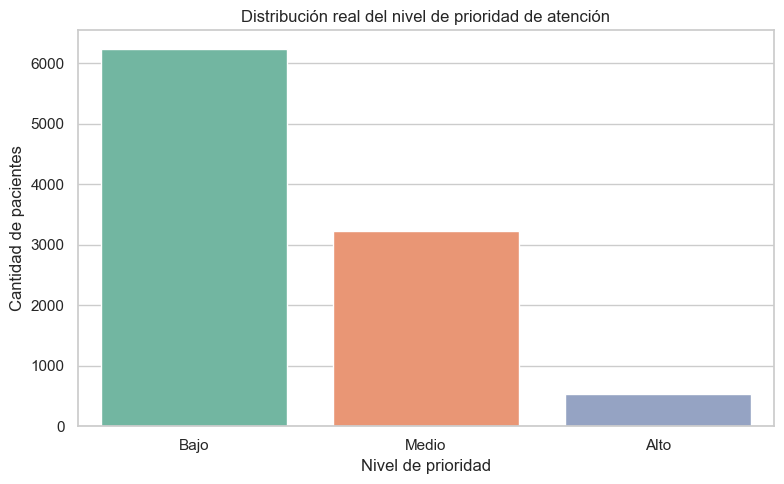

In [9]:
plt.figure(figsize=(8, 5))
order = [label for label in ["Bajo", "Medio", "Alto"] if label in df[TARGET].dropna().unique()]
sns.countplot(data=df, x=TARGET, order=order if order else None, palette="Set2")
plt.title("Distribución real del nivel de prioridad de atención")
plt.xlabel("Nivel de prioridad")
plt.ylabel("Cantidad de pacientes")
plt.tight_layout()
plt.show()

## 6. Preparación de datos

Se seleccionan las variables predictoras sugeridas, se elimina la variable objetivo y se descartan filas sin target. Las columnas identificadoras o de fechas no se usan como predictores.

In [10]:
suggested_features = [
    "edad",
    "dias_hospedaje",
    "num_controles_mes",
    "num_quimios_mes",
    "hemoglobina_g_dl",
    "neutrofilos",
    "plaquetas",
    "temperatura_c",
    "peso_kg",
    "imc",
    "distancia_origen_km",
    "ingreso_familiar_mensual",
    "acompanante_presente",
    "requiere_apoyo_psicosocial",
    "sexo",
    "region_origen",
    "diagnostico_general",
    "estado_tratamiento",
    "seguro_salud",
    "alfabetizacion_digital",
]

identifier_or_date_cols = ["paciente_id", "fecha_registro"]
available_features = [col for col in suggested_features if col in df.columns]
missing_features = [col for col in suggested_features if col not in df.columns]

if missing_features:
    print("Variables sugeridas no encontradas en el dataset:")
    print(missing_features)

model_df = df.dropna(subset=[TARGET]).copy()
X = model_df[available_features].copy()
y = model_df[TARGET].copy()

print(f"Filas disponibles para modelamiento: {len(model_df)}")
print(f"Número de variables predictoras usadas: {len(available_features)}")
print("Columnas identificadoras/fechas excluidas si existían:", [c for c in identifier_or_date_cols if c in df.columns])

Filas disponibles para modelamiento: 10000
Número de variables predictoras usadas: 20
Columnas identificadoras/fechas excluidas si existían: ['paciente_id', 'fecha_registro']


In [11]:
numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number", "bool"]).columns.tolist()

print("Variables numéricas:")
print(numeric_features)
print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['edad', 'dias_hospedaje', 'num_controles_mes', 'num_quimios_mes', 'hemoglobina_g_dl', 'neutrofilos', 'plaquetas', 'temperatura_c', 'peso_kg', 'imc', 'distancia_origen_km', 'ingreso_familiar_mensual', 'acompanante_presente', 'requiere_apoyo_psicosocial']

Variables categóricas:
['sexo', 'region_origen', 'diagnostico_general', 'estado_tratamiento', 'seguro_salud', 'alfabetizacion_digital']


In [12]:
try:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    # Compatibilidad con versiones anteriores de scikit-learn.
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", onehot_encoder),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

baseline_model = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    max_depth=5,
    class_weight="balanced",
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", baseline_model),
    ]
)

pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 7. División train/test

Se usa división estratificada para conservar la proporción de clases del target en entrenamiento y prueba.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print("\nDistribución del target en train (%):")
display(y_train.value_counts(normalize=True).mul(100).round(2).to_frame("porcentaje"))
print("\nDistribución del target en test (%):")
display(y_test.value_counts(normalize=True).mul(100).round(2).to_frame("porcentaje"))

X_train: (8000, 20)
X_test: (2000, 20)

Distribución del target en train (%):


,porcentaje
nivel_prioridad_atencion,
Bajo,62.32
Medio,32.35
Alto,5.32



Distribución del target en test (%):


,porcentaje
nivel_prioridad_atencion,
Bajo,62.30
Medio,32.35
Alto,5.35


## 8. Entrenamiento del modelo baseline

In [14]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Modelo baseline entrenado correctamente.")

Modelo baseline entrenado correctamente.


## 9. Evaluación del modelo

In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
precision_weighted = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)

metrics_summary = pd.DataFrame(
    {
        "metrica": [
            "accuracy",
            "precision_macro",
            "recall_macro",
            "f1_macro",
            "precision_weighted",
            "recall_weighted",
            "f1_weighted",
        ],
        "valor": [
            accuracy,
            precision_macro,
            recall_macro,
            f1_macro,
            precision_weighted,
            recall_weighted,
            f1_weighted,
        ],
    }
)

display(metrics_summary)

,metrica,valor
0,accuracy,0.808500
1,precision_macro,0.714579
2,recall_macro,0.781394
3,f1_macro,0.740786
4,precision_weighted,0.826702
5,recall_weighted,0.808500
6,f1_weighted,0.814318


In [16]:
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()

print("Classification report:")
print(classification_report(y_test, y_pred, zero_division=0))
display(report_df)

Classification report:
              precision    recall  f1-score   support

        Alto       0.53      0.74      0.62       107
        Bajo       0.93      0.83      0.88      1246
       Medio       0.68      0.77      0.73       647

    accuracy                           0.81      2000
   macro avg       0.71      0.78      0.74      2000
weighted avg       0.83      0.81      0.81      2000



,precision,recall,f1-score,support
Alto,0.533784,0.738318,0.619608,107.0000
Bajo,0.925959,0.833066,0.877060,1246.0000
Medio,0.683995,0.772798,0.725689,647.0000
accuracy,0.808500,0.808500,0.808500,0.8085
macro avg,0.714579,0.781394,0.740786,2000.0000
weighted avg,0.826702,0.808500,0.814318,2000.0000


In [17]:
labels = [label for label in ["Bajo", "Medio", "Alto"] if label in sorted(y.unique())]
if not labels:
    labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"Real_{c}" for c in labels], columns=[f"Pred_{c}" for c in labels])
display(cm_df)

,Pred_Bajo,Pred_Medio,Pred_Alto
Real_Bajo,1038,203,5
Real_Medio,83,500,64
Real_Alto,0,28,79


## 10. Visualización de matriz de confusión

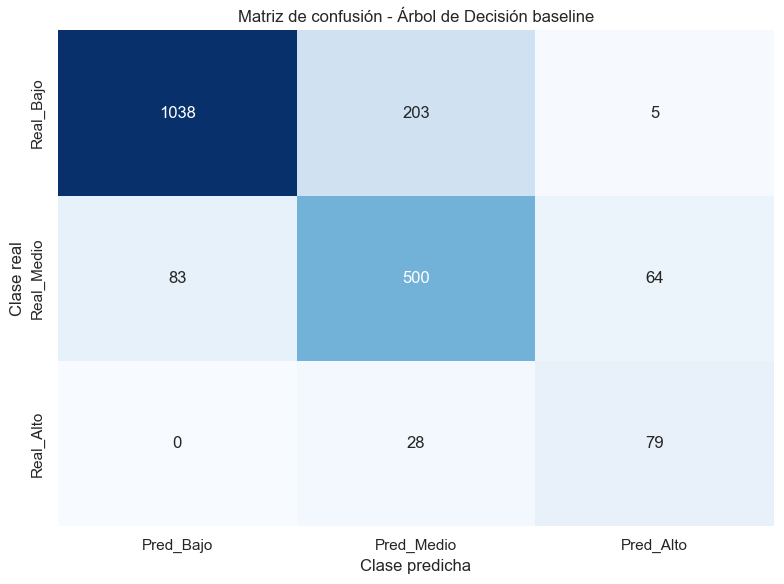

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - Árbol de Decisión baseline")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()

## 11. Importancia de variables

In [19]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
feature_importances = pipeline.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"variable": feature_names, "importancia": feature_importances})
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

importance_df["variable"] = (
    importance_df["variable"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

display(importance_df.head(20))

,variable,importancia
0,neutrofilos,3.399606e-01
1,hemoglobina_g_dl,2.594882e-01
2,temperatura_c,1.936235e-01
3,plaquetas,1.295318e-01
4,estado_tratamiento_Recaída,2.312840e-02
5,dias_hospedaje,2.058752e-02
6,peso_kg,6.749058e-03
7,num_quimios_mes,5.938290e-03
8,imc,5.670810e-03
9,distancia_origen_km,5.528197e-03


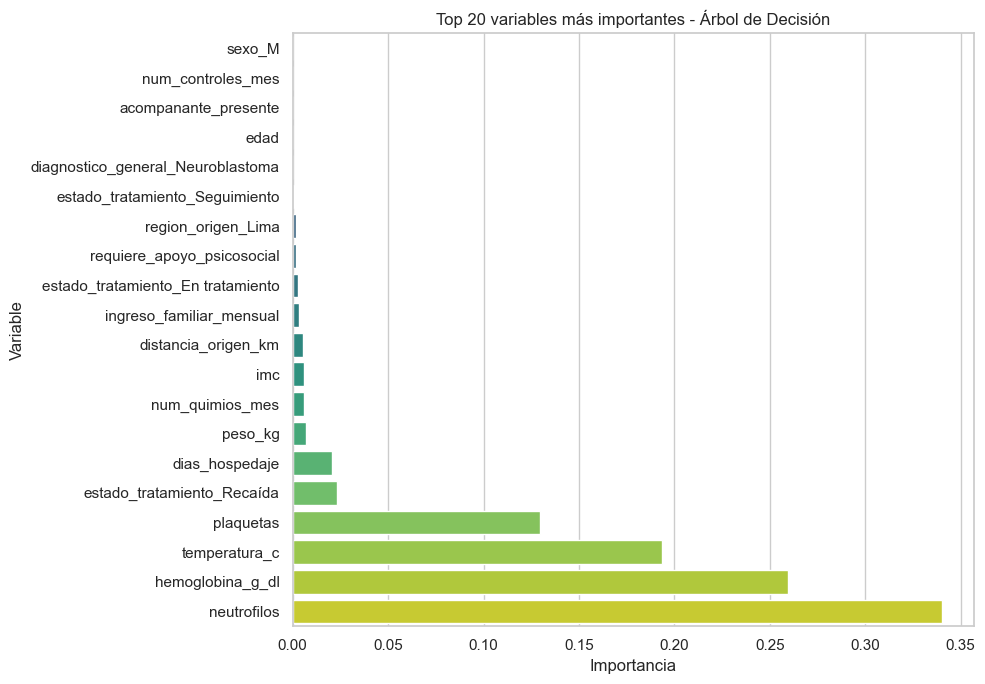

In [20]:
top_n = 20
top_importance = importance_df.head(top_n).sort_values("importancia", ascending=True)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_importance, x="importancia", y="variable", palette="viridis")
plt.title(f"Top {top_n} variables más importantes - Árbol de Decisión")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 12. Guardado de resultados

Se guardan los resultados principales en la carpeta relativa `outputs_baseline`.

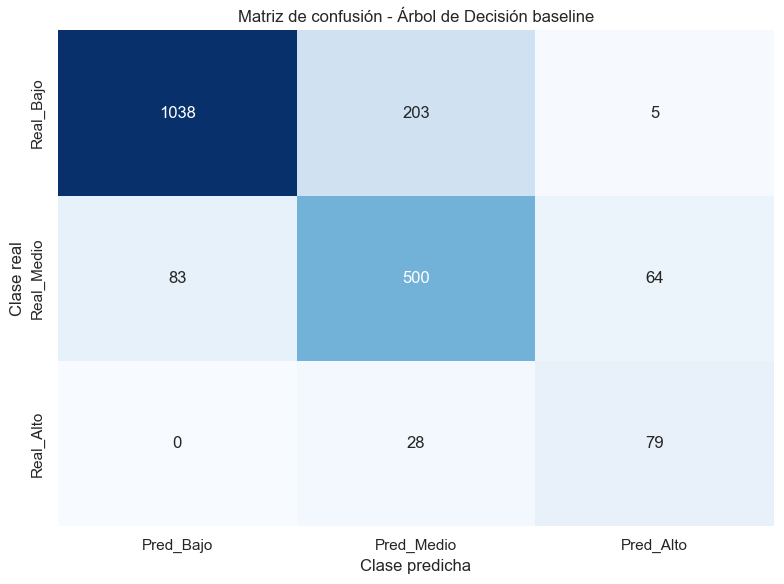

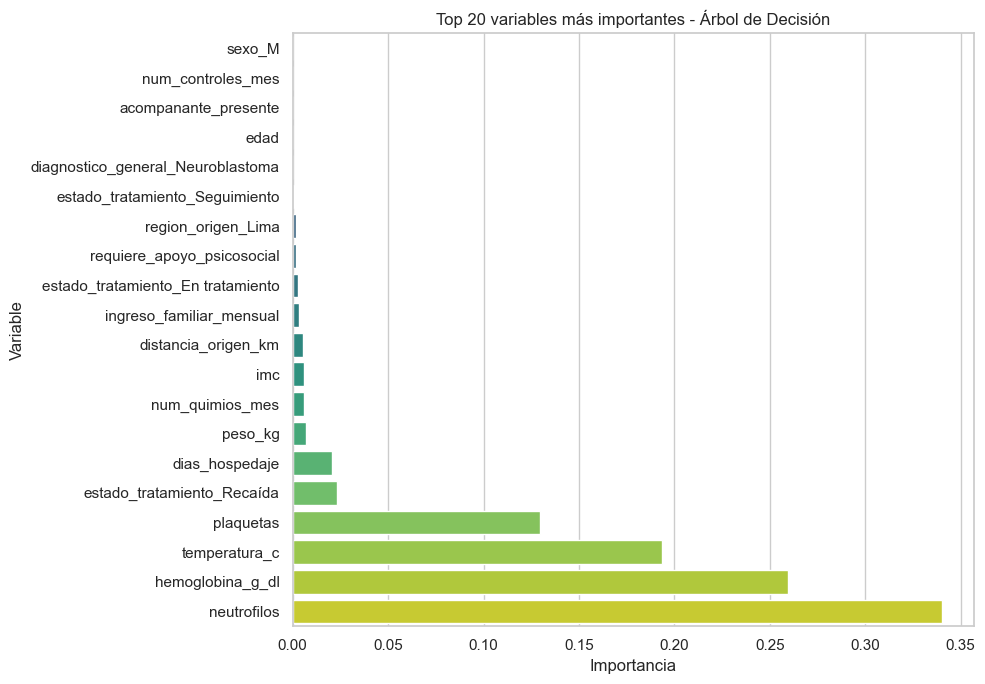

Resultados guardados en: outputs_baseline


In [21]:
OUTPUT_DIR = BASE_DIR / "outputs_baseline"
OUTPUT_DIR.mkdir(exist_ok=True)

report_df.to_csv(OUTPUT_DIR / "classification_report_baseline.csv", index=True)
cm_df.to_csv(OUTPUT_DIR / "confusion_matrix_baseline.csv", index=True)
metrics_summary.to_csv(OUTPUT_DIR / "metrics_summary_baseline.csv", index=False)
importance_df.to_csv(OUTPUT_DIR / "feature_importance_baseline.csv", index=False)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - Árbol de Decisión baseline")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 7))
sns.barplot(data=top_importance, x="importancia", y="variable", palette="viridis")
plt.title(f"Top {top_n} variables más importantes - Árbol de Decisión")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importance_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Resultados guardados en: {OUTPUT_DIR.relative_to(BASE_DIR)}")

## 13. Baseline 2: prediccion de stock critico a 7 dias

Este segundo modelo es un baseline para cubrir el frente logistico de prediccion de stock critico solicitado en el proyecto ALDIMI.

### 13.1 Carga del dataset de inventario

In [22]:
stock_csv_path = DATA_DIR / "consumo_inventario_diario_sintetico.csv"

if not stock_csv_path.exists():
    raise FileNotFoundError(
        "No se encontro consumo_inventario_diario_sintetico.csv. "
        "Verifica que el ZIP este descomprimido y que la carpeta datos exista."
    )

df_stock = pd.read_csv(stock_csv_path)
print(f"Archivo de inventario localizado en: {stock_csv_path.relative_to(BASE_DIR)}")
print(f"Dimensiones del dataset de inventario: {df_stock.shape[0]} filas x {df_stock.shape[1]} columnas")
display(df_stock.head())

Archivo de inventario localizado en: ALDIMI_synthetic_dataset_v2_ampliado\datos\consumo_inventario_diario_sintetico.csv
Dimensiones del dataset de inventario: 18000 filas x 15 columnas


,fecha,item_id,nombre_item,categoria,unidad_medida,ocupacion_familias,stock_inicio,ingreso_stock,consumo_real,stock_fin,consumo_estimado_7d,consumo_estimado_14d,dias_cobertura,stock_critico_7d,stock_critico_14d
0,2025-01-01,ITM001,Arroz,alimentos,kg,51,206,0,15.40,191,99.96,199.92,13.38,0,1
1,2025-01-01,ITM002,Avena,alimentos,kg,51,108,0,6.96,101,42.84,85.68,16.50,0,0
2,2025-01-01,ITM003,Leche evaporada,alimentos,lata,51,232,0,19.27,213,124.95,249.90,11.93,0,1
3,2025-01-01,ITM004,Menestras,alimentos,kg,51,116,0,9.89,106,64.26,128.52,11.55,0,1
4,2025-01-01,ITM005,Aceite vegetal,alimentos,litro,51,73,0,3.40,70,21.42,42.84,22.88,0,0


### 13.2 Revision de nulos y distribucion del target

In [23]:
STOCK_TARGET = "stock_critico_7d"

if STOCK_TARGET not in df_stock.columns:
    raise ValueError(f"No se encontro la variable objetivo: {STOCK_TARGET}")

print("Nulos por columna en el dataset de inventario:")
stock_nulls = df_stock.isnull().sum().sort_values(ascending=False).to_frame("nulos")
display(stock_nulls)

stock_target_summary = pd.concat(
    [
        df_stock[STOCK_TARGET].value_counts(dropna=False).rename("conteo"),
        df_stock[STOCK_TARGET]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
        .rename("porcentaje"),
    ],
    axis=1,
)
display(stock_target_summary)

Nulos por columna en el dataset de inventario:


,nulos
consumo_real,106
item_id,0
fecha,0
categoria,0
unidad_medida,0
ocupacion_familias,0
nombre_item,0
stock_inicio,0
ingreso_stock,0
stock_fin,0


,conteo,porcentaje
stock_critico_7d,,
1,12831,71.28
0,5169,28.72


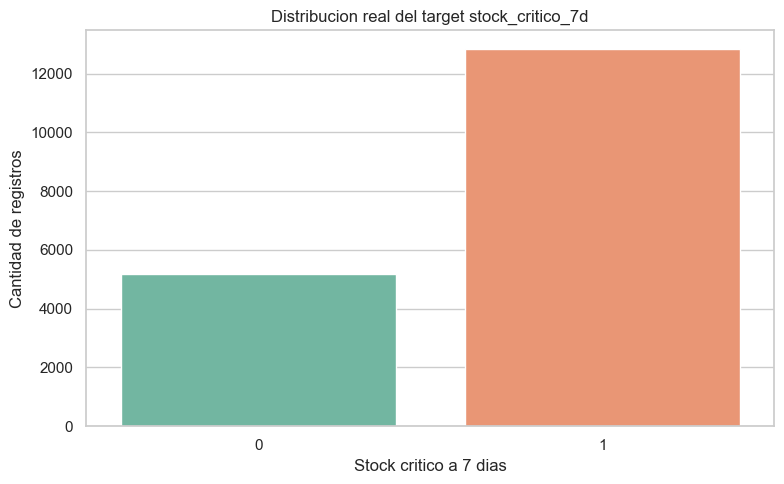

In [24]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_stock, x=STOCK_TARGET, palette="Set2")
plt.title("Distribucion real del target stock_critico_7d")
plt.xlabel("Stock critico a 7 dias")
plt.ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()

### 13.3 Preparacion corregida sin fuga de informacion

Las variables sugeridas originalmente incluian indicadores derivados o posteriores que explican directamente el target. Para evitar una evaluacion artificialmente perfecta, se excluyen estas columnas antes del entrenamiento:

- `stock_fin`
- `consumo_estimado_7d`
- `consumo_estimado_14d`
- `dias_cobertura`

In [25]:
stock_features_original_suggested = [
    "ocupacion_familias",
    "stock_inicio",
    "ingreso_stock",
    "consumo_real",
    "stock_fin",
    "consumo_estimado_7d",
    "consumo_estimado_14d",
    "dias_cobertura",
    "categoria",
    "unidad_medida",
    "item_id",
]

stock_leakage_features = [
    "stock_fin",
    "consumo_estimado_7d",
    "consumo_estimado_14d",
    "dias_cobertura",
]

stock_features_suggested = [
    col for col in stock_features_original_suggested
    if col not in stock_leakage_features
]

print("Variables excluidas para evitar fuga de informacion:")
print([col for col in stock_leakage_features if col in df_stock.columns])

print("\nVariables usadas por el modelo de stock corregido:")
print(stock_features_suggested)

stock_available_features = [col for col in stock_features_suggested if col in df_stock.columns]
stock_missing_features = [col for col in stock_features_suggested if col not in df_stock.columns]
stock_leakage_detected = [col for col in stock_available_features if col in stock_leakage_features]

assert not stock_leakage_detected, f"Se detectaron variables con fuga en X_stock: {stock_leakage_detected}"

if stock_missing_features:
    print("Variables sugeridas no encontradas en el dataset de inventario:")
    print(stock_missing_features)

stock_model_df = df_stock.dropna(subset=[STOCK_TARGET]).copy()
X_stock = stock_model_df[stock_available_features].copy()
y_stock = stock_model_df[STOCK_TARGET].copy()

stock_numeric_features = X_stock.select_dtypes(include=["number", "bool"]).columns.tolist()
stock_categorical_features = X_stock.select_dtypes(exclude=["number", "bool"]).columns.tolist()

print(f"Filas disponibles para modelamiento de stock: {len(stock_model_df)}")
print(f"Numero de variables predictoras usadas: {len(stock_available_features)}")
print("Variables numericas:", stock_numeric_features)
print("Variables categoricas:", stock_categorical_features)

Variables excluidas para evitar fuga de informacion:
['stock_fin', 'consumo_estimado_7d', 'consumo_estimado_14d', 'dias_cobertura']

Variables usadas por el modelo de stock corregido:
['ocupacion_familias', 'stock_inicio', 'ingreso_stock', 'consumo_real', 'categoria', 'unidad_medida', 'item_id']
Filas disponibles para modelamiento de stock: 18000
Numero de variables predictoras usadas: 7
Variables numericas: ['ocupacion_familias', 'stock_inicio', 'ingreso_stock', 'consumo_real']
Variables categoricas: ['categoria', 'unidad_medida', 'item_id']


### 13.4 Pipeline de preprocesamiento y modelo

In [26]:
try:
    stock_onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    stock_onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

stock_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

stock_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", stock_onehot_encoder),
    ]
)

stock_preprocessor = ColumnTransformer(
    transformers=[
        ("num", stock_numeric_transformer, stock_numeric_features),
        ("cat", stock_categorical_transformer, stock_categorical_features),
    ],
    remainder="drop",
)

stock_baseline_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)

stock_pipeline = Pipeline(
    steps=[
        ("preprocessor", stock_preprocessor),
        ("model", stock_baseline_model),
    ]
)

stock_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 13.5 Division train/test con estratificacion

In [27]:
X_stock_train, X_stock_test, y_stock_train, y_stock_test = train_test_split(
    X_stock,
    y_stock,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_stock,
)

print(f"X_stock_train: {X_stock_train.shape}")
print(f"X_stock_test: {X_stock_test.shape}")
print("Distribucion del target stock en train (%):")
display(y_stock_train.value_counts(normalize=True).mul(100).round(2).to_frame("porcentaje"))
print("Distribucion del target stock en test (%):")
display(y_stock_test.value_counts(normalize=True).mul(100).round(2).to_frame("porcentaje"))

X_stock_train: (14400, 7)
X_stock_test: (3600, 7)
Distribucion del target stock en train (%):


,porcentaje
stock_critico_7d,
1,71.28
0,28.72


Distribucion del target stock en test (%):


,porcentaje
stock_critico_7d,
1,71.28
0,28.72


### 13.6 Entrenamiento y evaluacion del baseline complementario

In [28]:
stock_pipeline.fit(X_stock_train, y_stock_train)
y_stock_pred = stock_pipeline.predict(X_stock_test)

stock_accuracy = accuracy_score(y_stock_test, y_stock_pred)
stock_precision_macro = precision_score(y_stock_test, y_stock_pred, average="macro", zero_division=0)
stock_recall_macro = recall_score(y_stock_test, y_stock_pred, average="macro", zero_division=0)
stock_f1_macro = f1_score(y_stock_test, y_stock_pred, average="macro", zero_division=0)
stock_precision_weighted = precision_score(y_stock_test, y_stock_pred, average="weighted", zero_division=0)
stock_recall_weighted = recall_score(y_stock_test, y_stock_pred, average="weighted", zero_division=0)
stock_f1_weighted = f1_score(y_stock_test, y_stock_pred, average="weighted", zero_division=0)

stock_metrics_summary = pd.DataFrame(
    {
        "metrica": [
            "accuracy",
            "precision_macro",
            "recall_macro",
            "f1_macro",
            "precision_weighted",
            "recall_weighted",
            "f1_weighted",
        ],
        "valor": [
            stock_accuracy,
            stock_precision_macro,
            stock_recall_macro,
            stock_f1_macro,
            stock_precision_weighted,
            stock_recall_weighted,
            stock_f1_weighted,
        ],
    }
)

display(stock_metrics_summary)

,metrica,valor
0,accuracy,0.870833
1,precision_macro,0.837662
2,recall_macro,0.862622
3,f1_macro,0.848165
4,precision_weighted,0.878317
5,recall_weighted,0.870833
6,f1_weighted,0.873131


In [29]:
stock_report_dict = classification_report(y_stock_test, y_stock_pred, output_dict=True, zero_division=0)
stock_report_df = pd.DataFrame(stock_report_dict).transpose()

print("Classification report - baseline stock critico corregido:")
print(classification_report(y_stock_test, y_stock_pred, zero_division=0))
display(stock_report_df)

Classification report - baseline stock critico corregido:
              precision    recall  f1-score   support

           0       0.74      0.84      0.79      1034
           1       0.93      0.88      0.91      2566

    accuracy                           0.87      3600
   macro avg       0.84      0.86      0.85      3600
weighted avg       0.88      0.87      0.87      3600



,precision,recall,f1-score,support
0,0.742128,0.843327,0.789498,1034.000000
1,0.933196,0.881917,0.906832,2566.000000
accuracy,0.870833,0.870833,0.870833,0.870833
macro avg,0.837662,0.862622,0.848165,3600.000000
weighted avg,0.878317,0.870833,0.873131,3600.000000


In [30]:
stock_labels = sorted(y_stock.unique())
stock_cm = confusion_matrix(y_stock_test, y_stock_pred, labels=stock_labels)
stock_cm_df = pd.DataFrame(
    stock_cm,
    index=[f"Real_{c}" for c in stock_labels],
    columns=[f"Pred_{c}" for c in stock_labels],
)
display(stock_cm_df)

,Pred_0,Pred_1
Real_0,872,162
Real_1,303,2263


### 13.7 Matriz de confusion e importancia de variables

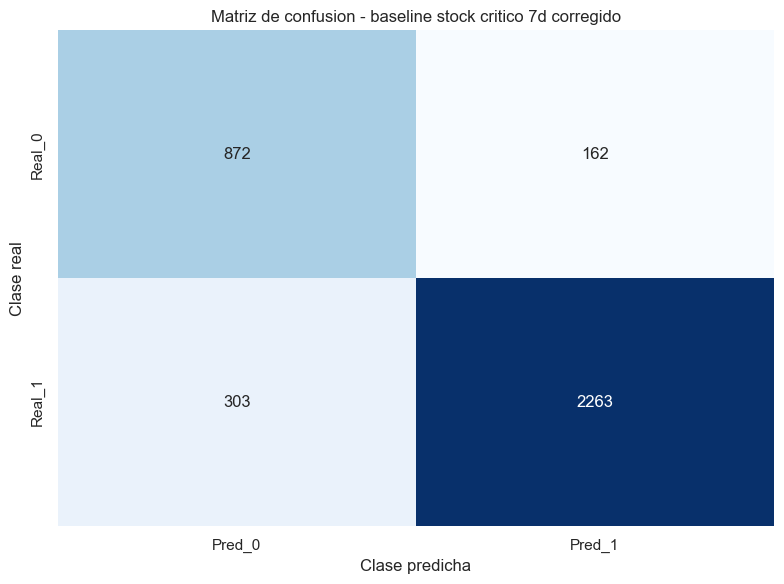

In [31]:
plt.figure(figsize=(8, 6))
sns.heatmap(stock_cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusion - baseline stock critico 7d corregido")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()

In [32]:
stock_feature_names = stock_pipeline.named_steps["preprocessor"].get_feature_names_out()
stock_feature_importances = stock_pipeline.named_steps["model"].feature_importances_

stock_importance_df = (
    pd.DataFrame({"variable": stock_feature_names, "importancia": stock_feature_importances})
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

stock_importance_df["variable"] = (
    stock_importance_df["variable"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

display(stock_importance_df.head(20))

,variable,importancia
0,stock_inicio,0.421519
1,consumo_real,0.355193
2,ingreso_stock,0.203406
3,ocupacion_familias,0.017889
4,unidad_medida_frasco,0.001506
5,item_id_ITM006,0.000487
6,categoria_higiene,0.000000
7,categoria_insumos_medicos,0.000000
8,categoria_medicamentos_soporte,0.000000
9,unidad_medida_kg,0.000000


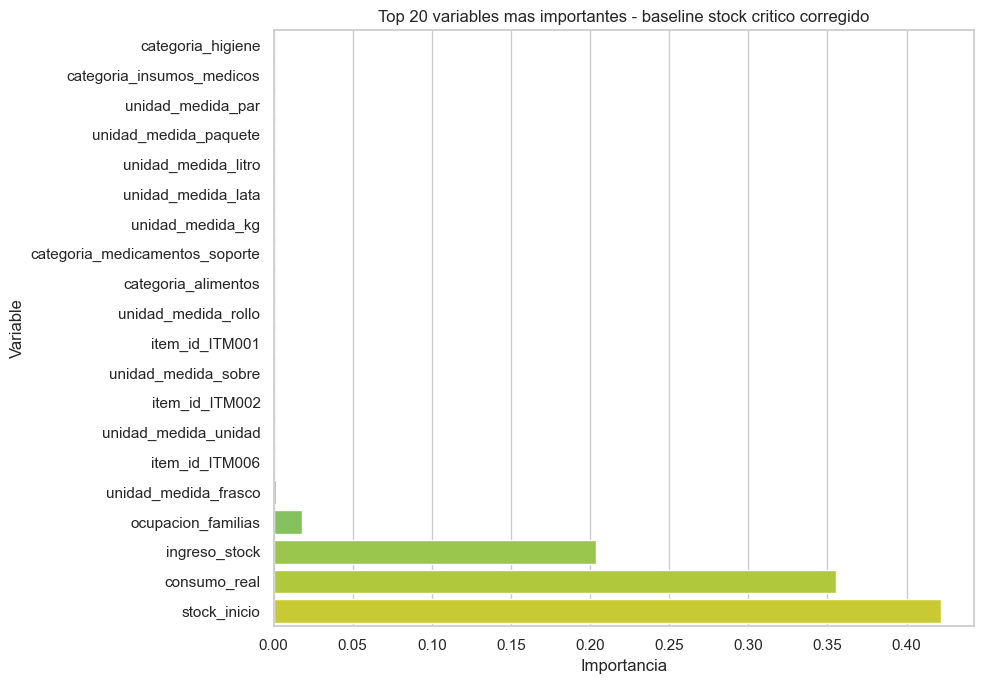

In [33]:
stock_top_n = 20
stock_top_importance = stock_importance_df.head(stock_top_n).sort_values("importancia", ascending=True)

plt.figure(figsize=(10, 7))
sns.barplot(data=stock_top_importance, x="importancia", y="variable", palette="viridis")
plt.title(f"Top {stock_top_n} variables mas importantes - baseline stock critico corregido")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### 13.8 Guardado de resultados del baseline complementario

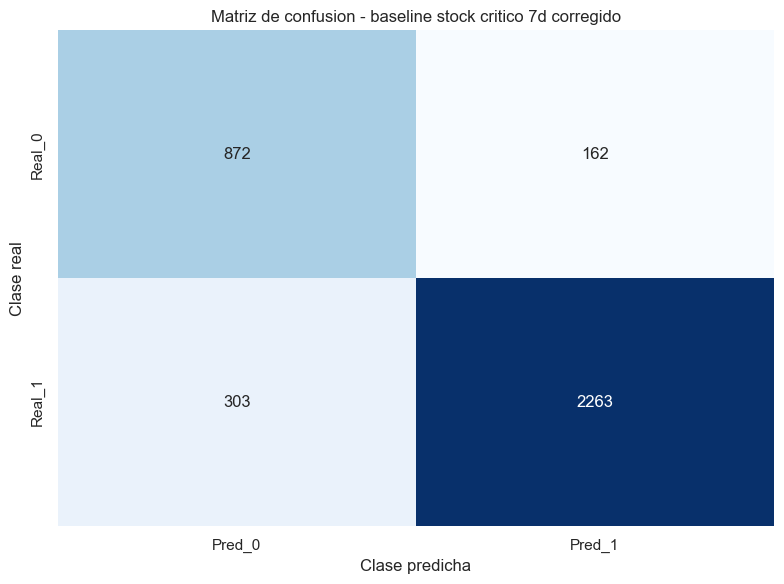

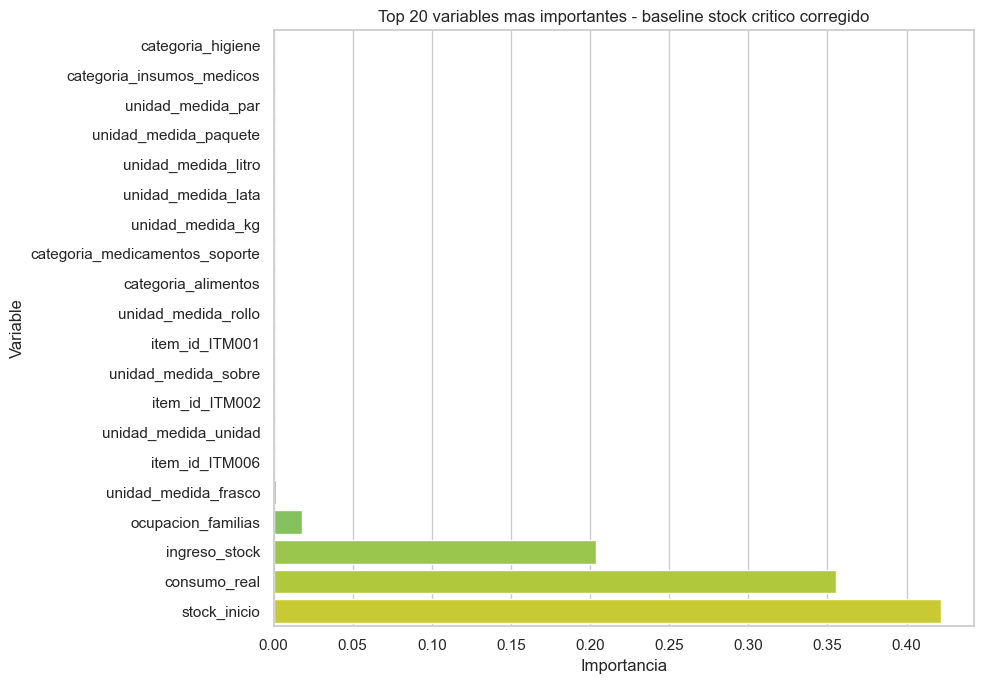

Resultados del baseline de stock guardados en: outputs_baseline_stock


In [34]:
STOCK_OUTPUT_DIR = BASE_DIR / "outputs_baseline_stock"
STOCK_OUTPUT_DIR.mkdir(exist_ok=True)

stock_report_df.to_csv(STOCK_OUTPUT_DIR / "classification_report_stock_baseline.csv", index=True)
stock_cm_df.to_csv(STOCK_OUTPUT_DIR / "confusion_matrix_stock_baseline.csv", index=True)
stock_metrics_summary.to_csv(STOCK_OUTPUT_DIR / "metrics_summary_stock_baseline.csv", index=False)
stock_importance_df.to_csv(STOCK_OUTPUT_DIR / "feature_importance_stock_baseline.csv", index=False)

plt.figure(figsize=(8, 6))
sns.heatmap(stock_cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusion - baseline stock critico 7d corregido")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.savefig(STOCK_OUTPUT_DIR / "confusion_matrix_stock_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 7))
sns.barplot(data=stock_top_importance, x="importancia", y="variable", palette="viridis")
plt.title(f"Top {stock_top_n} variables mas importantes - baseline stock critico corregido")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig(STOCK_OUTPUT_DIR / "feature_importance_stock_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Resultados del baseline de stock guardados en: {STOCK_OUTPUT_DIR.relative_to(BASE_DIR)}")